In [2]:
# Import public packages and functions
import os
import pandas as pd
import numpy as np
import sys
import json
from pathlib import Path
from scipy import signal

import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from statsmodels.stats.multitest import multipletests

from joblib import Parallel, delayed
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

# inserting the lib folder to the compiler
sys.path.insert(0, './lib')
sys.path.insert(0, './utils/')

import utils_io, utils_trgc, utils_plotting_trgc, utils_plotting

from lib_data import DATA_IO

In [3]:
PATH_CURR = os.path.abspath(os.curdir)    # current code
PATH      = (str(Path(PATH_CURR).parent)) # data repository: upper directory where datasets situated
fs        = 2048

# 1. Data Load & Preprocess

In [3]:
# load ECoG events
EVENTS_ECOG            = utils_io.load_ECoG_events(event_category="tapping", fs=2048)
EVENTS_ECOG_LID        = EVENTS_ECOG['controlateral']['LID']
EVENTS_ECOG_noLID      = EVENTS_ECOG['controlateral']['noLID']
# load LFP events
EVENTS_LFP             = utils_io.load_LFP_events(event_category="tapping", stn_areas=["motor"], fs=2048)
EVENTS_LFP_MOTOR_LID   = EVENTS_LFP['motor']['controlateral']['LID']
EVENTS_LFP_MOTOR_noLID = EVENTS_LFP['motor']['controlateral']['noLID']

In [6]:
# add state information
EVENTS_ECOG_noLID["severity"]                                                              = "MED-OFF"
EVENTS_ECOG_noLID.loc[(EVENTS_ECOG_noLID['event_start_time'] >= 30), 'severity']           = 'MED-ON'
EVENTS_ECOG_LID["severity"]                                                                = "LID"
EVENTS_LFP_MOTOR_noLID["severity"]                                                         = "MED-OFF"
EVENTS_LFP_MOTOR_noLID.loc[(EVENTS_LFP_MOTOR_noLID['event_start_time'] >= 30), 'severity'] = 'MED-ON'
EVENTS_LFP_MOTOR_LID["severity"]                                                           = "LID"

dataset_LFP  = pd.concat([EVENTS_LFP_MOTOR_noLID, EVENTS_LFP_MOTOR_LID], ignore_index=True)
dataset_ECOG = pd.concat([EVENTS_ECOG_LID, EVENTS_ECOG_noLID], ignore_index=True)

dataset_LFP  = dataset_LFP[dataset_LFP.patient.isin(dataset_ECOG.patient.unique().tolist())]
dataset_LFP.reset_index(drop=True, inplace=True)

dataset_LFP  = dataset_LFP[['patient', 'event_no', 'LFP_hemisphere', 'LFP_channel', 'pre_event_recording', 'event_recording', 'post_event_recording', 'severity']]
dataset_ECOG = dataset_ECOG[['patient', 'event_no', 'ECoG_hemisphere', 'ECoG_channel', 'pre_event_recording', 'event_recording', 'post_event_recording', 'severity']]

del EVENTS_ECOG, EVENTS_ECOG_LID, EVENTS_ECOG_noLID, EVENTS_LFP, EVENTS_LFP_MOTOR_LID, EVENTS_LFP_MOTOR_noLID

# 2. Time-Reversed Granger Causality

## 2.1 Tapping Activity

In [14]:
connectivity_side = "ipsilateral"
data_gc           = []

for state in ["MED-OFF", "MED-ON", "LID"]:
    for direction in ["lfp->ecog", "ecog->lfp"]:
        for patient in dataset_ECOG[dataset_ECOG.severity==state].patient.unique():
            for segment in ["pre_event", "event", "post_event"]:

                print(f"processing patient {patient} | {direction} direction | {state} state | {segment} segment... ")
                patient_gc = utils_trgc.measure_granger_causality_between_STN_and_cortex(dataset_LFP       = dataset_LFP, 
                                                                                         dataset_ECOG      = dataset_ECOG, 
                                                                                         state             = state, 
                                                                                         direction         = direction, 
                                                                                         patient           = patient, 
                                                                                         segment           = segment, 
                                                                                         connectivity_side = connectivity_side,
                                                                                         fs                = fs, 
                                                                                         n_iteration       = 100)
                if not (np.isscalar(patient_gc) and np.isnan(patient_gc)):
                    data_gc.append(patient_gc)

data_gc = pd.concat(data_gc, ignore_index=True)

processing patient 009 | lfp->ecog direction | MED-OFF state | pre_event segment... 
>>> pre-event recordings have consistent length  : True
>>> >>> bootstrap testing with 100 iterations
>>> >>> >>> 100 iteration completed...
processing patient 009 | lfp->ecog direction | MED-OFF state | event segment... 
>>> event recordings have consistent length      : True
>>> >>> bootstrap testing with 100 iterations
>>> >>> >>> 100 iteration completed...
processing patient 009 | lfp->ecog direction | MED-OFF state | post_event segment... 
>>> post event recordings have consistent length : True
>>> >>> bootstrap testing with 100 iterations
>>> >>> >>> 100 iteration completed...
processing patient 010 | lfp->ecog direction | MED-OFF state | pre_event segment... 
>>> >>> >>> Patient 010 does not have LFP or ECOG recordings for MED-OFF state to estimate connectivity...
processing patient 010 | lfp->ecog direction | MED-OFF state | event segment... 
>>> >>> >>> Patient 010 does not have LFP or ECOG re

In [33]:
data_gc.to_pickle(DATA_IO.path_events + "granger_causality/ipsilateral_connectivity_.pkl")

## 2.2 Baseline Recordings

In [3]:
baseline_gc = utils_connectivity.measure_baseline_granger_causality_between_STN_and_cortex(connectivity_side="ipsilateral", fs=fs)
baseline_gc.to_pickle(DATA_IO.path_events + "granger_causality/baseline_ipsilateral_connectivity.pkl")

Patient 008: does not have right hemisphere baseline recordings
Patient 009: does not have right hemisphere baseline recordings
Patient 010: does not have left hemisphere baseline recordings
Patient 012: does not have left hemisphere baseline recordings
Patient 013: does not have left hemisphere baseline recordings
Patient 014: does not have left hemisphere baseline recordings
Patient 016: does not have left hemisphere baseline recordings
Patient 017: does not have left hemisphere baseline recordings
Patient 020: does not have left hemisphere baseline recordings
Patient 021: does not have left hemisphere baseline recordings
Patient 022: does not have left hemisphere baseline recordings
Patient 023: does not have left hemisphere baseline recordings
Patient 101: does not have right hemisphere baseline recordings
Patient 101: does not have left hemisphere baseline recordings
Patient 102: does not have right hemisphere baseline recordings
Patient 102: does not have left hemisphere baseline

## 2.3 Normalization

In [3]:
baseline_gc   = pd.read_pickle(DATA_IO.path_events + "granger_causality/baseline_ipsilateral_connectivity.pkl")
taps_gc       = pd.read_pickle(DATA_IO.path_events + "granger_causality/ipsilateral_connectivity.pkl")
normalized_gc = utils_connectivity.normalize_gc_by_baseline(taps_gc, baseline_gc)

# 3. Statistical Tests For Directional [Cortex to STN] Granger Causality

In [5]:
taps_gc = pd.read_pickle(DATA_IO.path_events + "granger_causality/ipsilateral_connectivity.pkl")

## 3.1 Clinical State-Wise Differences [MED-OFF vs MED-ON & MED-ON vs LID]

In [7]:
results_lme_state = []

for frequency_band in ["theta", "alpha", "beta_low", "beta_high", "gamma"]:
    for segment in ["pre_event", "event", "post_event"]:
        
        results_lme_state.append(utils_trgc.compare_trgc_strength_across_states(dataset=taps_gc, direction="ecog->lfp", frequency_band=frequency_band, segment=segment))

results_lme_state                     = pd.concat(results_lme_state, ignore_index=True)
# correct the p-values for each comparison separately (i.e. correct all pvalues for MED-OFF vs MED-ON)
results_lme_state["pvalue_corrected"] = results_lme_state.groupby("reference_group")["pvalue"].transform(lambda p: multipletests(p, method="holm")[1])

<Figure size 640x480 with 0 Axes>

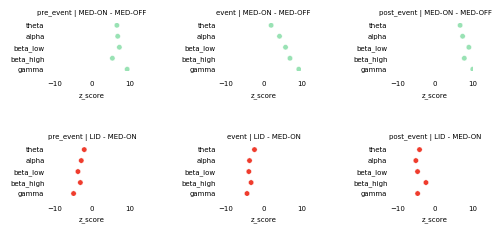

In [78]:
plt = utils_plotting.get_figure_template()
ax1 = plt.subplot2grid((77, 66), (0, 0)  , colspan=9, rowspan=6)
ax2 = plt.subplot2grid((77, 66), (0, 20) , colspan=9, rowspan=6)
ax3 = plt.subplot2grid((77, 66), (0, 40) , colspan=9, rowspan=6)

ax4 = plt.subplot2grid((77, 66), (15, 0) , colspan=9, rowspan=6)
ax5 = plt.subplot2grid((77, 66), (15, 20), colspan=9, rowspan=6)
ax6 = plt.subplot2grid((77, 66), (15, 40), colspan=9, rowspan=6)

ax1 = utils_plotting_trgc.plot_stats_between_states(results_lme_state, event_segment="pre_event" , reference_group="MED-OFF", comparison_group="MED-ON", axis=ax1)
ax2 = utils_plotting_trgc.plot_stats_between_states(results_lme_state, event_segment="event"     , reference_group="MED-OFF", comparison_group="MED-ON", axis=ax2)
ax3 = utils_plotting_trgc.plot_stats_between_states(results_lme_state, event_segment="post_event", reference_group="MED-OFF", comparison_group="MED-ON", axis=ax3)

ax4 = utils_plotting_trgc.plot_stats_between_states(results_lme_state, event_segment="pre_event" , reference_group="MED-ON", comparison_group="LID", axis=ax4)
ax5 = utils_plotting_trgc.plot_stats_between_states(results_lme_state, event_segment="event"     , reference_group="MED-ON", comparison_group="LID", axis=ax5)
ax6 = utils_plotting_trgc.plot_stats_between_states(results_lme_state, event_segment="post_event", reference_group="MED-ON", comparison_group="LID", axis=ax6)

plt.savefig(DATA_IO.path_figure + "granger_causality/lme_ECOGSTN_TFGC_between_states.svg", dpi=1200)

In [82]:
results_lme_state[results_lme_state.segment=="event"]

,reference_group,comparison_group,direction,segment,frequency_band,coefficient,z_score,pvalue,CI_lower,CI_upper,pvalue_corrected
2,MED-OFF,MED-ON,ecog->lfp,event,theta,0.004514,1.997924,4.572493e-02,0.000086,0.008943,4.572493e-02
3,MED-ON,LID,ecog->lfp,event,theta,-0.005912,-2.399342,1.642457e-02,-0.010742,-0.001083,4.817492e-02
8,MED-OFF,MED-ON,ecog->lfp,event,alpha,0.008447,4.207463,2.582542e-05,0.004512,0.012382,5.165084e-05
9,MED-ON,LID,ecog->lfp,event,alpha,-0.008197,-3.712372,2.053262e-04,-0.012525,-0.003869,1.481312e-03
14,MED-OFF,MED-ON,ecog->lfp,event,beta_low,0.011089,5.796513,6.770794e-09,0.007339,0.014838,2.708317e-08
15,MED-ON,LID,ecog->lfp,event,beta_low,-0.008334,-3.899156,9.652858e-05,-0.012523,-0.004145,8.687572e-04
20,MED-OFF,MED-ON,ecog->lfp,event,beta_high,0.010087,6.970419,3.159983e-12,0.007251,0.012923,2.527986e-11
21,MED-ON,LID,ecog->lfp,event,beta_high,-0.005356,-3.288588,1.006913e-03,-0.008549,-0.002164,6.041476e-03
26,MED-OFF,MED-ON,ecog->lfp,event,gamma,0.012406,9.297847,1.433184e-20,0.009791,0.015022,2.006458e-19
27,MED-ON,LID,ecog->lfp,event,gamma,-0.006624,-4.370326,1.240609e-05,-0.009594,-0.003653,1.364670e-04


## 3.2 Segment-Wise Differences Within Clinical States

In [84]:
dataset = taps_gc[taps_gc.source_type=="ECOG"].copy()
dataset = dataset.drop(["source_hemisphere", "source_index", "target_hemisphere", "target_index", "direction",
                        "gc_gamma_III", "pvalue_theta", "pvalue_alpha", "pvalue_beta_low", "pvalue_beta_high", "pvalue_gamma"], axis=1)

# first melt dataset into long format
dataset = dataset.melt(id_vars    = ["source_channel", "target_channel", "patient", "state", "segment"], # unique combinations
                       value_vars = ["gc_theta", "gc_alpha", "gc_beta_low", "gc_beta_high", "gc_gamma"],
                       var_name   = "frequency_band",
                       value_name = "gc_value")

# remove "gc_" prefix
dataset["frequency_band"] = dataset["frequency_band"].str.replace("gc_", "", regex=False)

In [86]:
results_lme_segment = []

for state in ["MED-OFF", "MED-ON", "LID"]:
    for frequency_band in ["theta", "alpha", "beta_low", "beta_high", "gamma"]:

        results = utils_trgc.compare_trgc_strength_across_segments_within_states(dataset=dataset, state=state, frequency_band=frequency_band)
        results_lme_segment.extend(results)

results_lme_segment                     = pd.DataFrame(results_lme_segment)
results_lme_segment["pvalue_corrected"] = results_lme_segment.groupby("state")["pvalue"].transform(lambda p: multipletests(p, method="holm")[1])

In [88]:
def plot_stats_between_segments_within_state(data, state, reference_group, comparison_group, axis):

    data_subset          = data[(data.reference_group==reference_group) & (data.comparison_group==comparison_group) & (data.state==state)].copy()
    data_subset['color'] = np.where(data_subset['pvalue_corrected'] > 0.05,'#ccccccff',  # non-significant
                                    np.where(data_subset['coefficient'] > 0,
                                             '#99e2b4ff',  # significant positive
                                             '#ef3c2dff'   # significant negative
                                            )
                                   )
    
    axis = sns.scatterplot(data=data_subset, y="frequency_band", x='z_score', c=data_subset.color.to_list(), s=15, ax=axis)
    axis.set_xlim([-10,10])
    axis.set_title(f"{state} | {comparison_group} - {reference_group}", fontsize=utils_plotting.LABEL_SIZE)
    axis.set_ylabel("")
    utils_plotting.set_axis(axis)

    return axis

<Figure size 640x480 with 0 Axes>

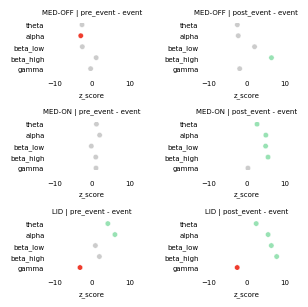

In [92]:
plt = utils_plotting.get_figure_template()

ax1 = plt.subplot2grid((77, 66), (0 , 0 ), colspan=9, rowspan=6)
ax2 = plt.subplot2grid((77, 66), (0 , 18), colspan=9, rowspan=6)
ax3 = plt.subplot2grid((77, 66), (12, 0 ), colspan=9, rowspan=6)
ax4 = plt.subplot2grid((77, 66), (12, 18), colspan=9, rowspan=6)
ax5 = plt.subplot2grid((77, 66), (24, 0 ), colspan=9, rowspan=6)
ax6 = plt.subplot2grid((77, 66), (24, 18), colspan=9, rowspan=6)

ax1 = plot_stats_between_segments_within_state(results_lme_segment, state="MED-OFF", reference_group="event", comparison_group="pre_event" , axis=ax1)
ax2 = plot_stats_between_segments_within_state(results_lme_segment, state="MED-OFF", reference_group="event", comparison_group="post_event", axis=ax2)

ax3 = plot_stats_between_segments_within_state(results_lme_segment, state="MED-ON" , reference_group="event", comparison_group="pre_event" , axis=ax3)
ax4 = plot_stats_between_segments_within_state(results_lme_segment, state="MED-ON" , reference_group="event", comparison_group="post_event", axis=ax4)

ax5 = plot_stats_between_segments_within_state(results_lme_segment, state="LID"    , reference_group="event", comparison_group="pre_event" , axis=ax5)
ax6 = plot_stats_between_segments_within_state(results_lme_segment, state="LID"    , reference_group="event", comparison_group="post_event", axis=ax6)

plt.savefig(DATA_IO.path_figure + "granger_causality/lme_ECOGSTN_TFGC_between_segments.svg", dpi=1200)

## 3.3 Differences Brain Cortices

In [7]:
# load MNI Coordinates of ECoG channels
MNI_ECoG_channels                = pd.read_pickle(DATA_IO.path_coordinates + "MNI_ECoG_channels.pkl")
MNI_ECoG_channels                = MNI_ECoG_channels[["patient", "hemisphere", "channel", "AAL3_cortex"]]
MNI_ECoG_channels["AAL3_cortex"] = MNI_ECoG_channels["AAL3_cortex"].replace({"Motor cortex": "motor", "Sensory cortex": "sensory",
                                                                   "Prefrontal cortex": "prefrontal", 'Parietal cortex':"parietal"})

dataset = taps_gc[taps_gc.source_type=="ECOG"].copy()
dataset = dataset.drop(["source_index", "target_hemisphere", "target_index", "direction",
                        "gc_gamma_III", "pvalue_theta", "pvalue_alpha", "pvalue_beta_low", "pvalue_beta_high", "pvalue_gamma"], axis=1)

# merge ECOG channel position with TRGC dataset
dataset = dataset.merge(MNI_ECoG_channels, left_on=["patient", "source_hemisphere", "source_channel"],
                               right_on=["patient", "hemisphere", "channel"], how="left", suffixes=("", "_source"))
dataset = dataset.drop(columns=["hemisphere", "channel"])

In [9]:
results_lme_cortices = []

for state in ["MED-OFF", "MED-ON", "LID"]:
    for frequency_band in ["theta", "alpha", "beta_low", "beta_high", "gamma"]:
       for segment in ["pre_event", "event", "post_event"]:

            results = utils_trgc.compare_trgc_strength_across_segments_within_cortical_areas(dataset        = dataset, 
                                                                                             state          = state,
                                                                                             segment        = segment,
                                                                                             frequency_band = frequency_band)
            results_lme_cortices.extend(results)

results_lme_cortices                     = pd.DataFrame(results_lme_cortices)
results_lme_cortices["pvalue_corrected"] = results_lme_cortices.groupby(["comparison_group"])["pvalue"].transform(lambda p: multipletests(p, method="holm")[1])

In [10]:
results_lme_cortices[results_lme_cortices.pvalue<=0.05]

,reference_group,comparison_group,direction,state,segment,frequency_band,coefficient,z_score,pvalue,CI_lower,CI_upper,pvalue_corrected
25,motor,parietal,ecog->lfp,MED-OFF,post_event,beta_low,-0.011033,-2.218163,0.026544,-0.020781,-0.001284,1.0
34,motor,parietal,ecog->lfp,MED-OFF,post_event,beta_high,-0.008993,-2.011237,0.044300,-0.017757,-0.000229,1.0
118,motor,parietal,ecog->lfp,LID,pre_event,beta_high,-0.005625,-2.129208,0.033237,-0.010804,-0.000447,1.0


# 4. Plotting Average Directional TRGC for Cortex

In [3]:
taps_gc = pd.read_pickle(DATA_IO.path_events + "granger_causality/ipsilateral_connectivity.pkl")

## 4.1 TFGC MED-OFF

In [7]:
vmin=0.005; vmax=0.020

utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-OFF", segment = "pre_event" , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-OFF", segment = "event"     , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-OFF", segment = "post_event", frequency_band = "gamma", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-OFF", segment = "pre_event" , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-OFF", segment = "event"     , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-OFF", segment = "post_event", frequency_band = "beta_high", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-OFF", segment = "pre_event" , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-OFF", segment = "event"     , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-OFF", segment = "post_event", frequency_band = "beta_low", vmin=vmin, vmax=vmax)

## 4.2 TFGC MED-ON

In [9]:
vmin=0.005; vmax=0.020

utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-ON", segment = "pre_event" , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-ON", segment = "event"     , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-ON", segment = "post_event", frequency_band = "gamma", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-ON", segment = "pre_event" , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-ON", segment = "event"     , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-ON", segment = "post_event", frequency_band = "beta_high", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-ON", segment = "pre_event" , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-ON", segment = "event"     , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "MED-ON", segment = "post_event", frequency_band = "beta_low", vmin=vmin, vmax=vmax)

## 4.3 TFGC LID

In [11]:
vmin=0.005; vmax=0.020

utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "LID", segment = "pre_event" , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "LID", segment = "event"     , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "LID", segment = "post_event", frequency_band = "gamma", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "LID", segment = "pre_event" , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "LID", segment = "event"     , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "LID", segment = "post_event", frequency_band = "beta_high", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "LID", segment = "pre_event" , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "LID", segment = "event"     , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_gc_connectivity_for_ECOG_channels(taps_gc, state = "LID", segment = "post_event", frequency_band = "beta_low", vmin=vmin, vmax=vmax)

## 4.4 TFGC Percentage of Significant Channel Pairs

In [16]:
taps_gc = pd.read_pickle(DATA_IO.path_events + "granger_causality/ipsilateral_connectivity.pkl")


In [18]:
state   = "LID"
segment = "event"

dataset = taps_gc[['source_type', 'source_hemisphere', 'source_channel', 'target_type', 'target_hemisphere', 'target_channel', 
                   'patient', 'state', 'segment', 'direction','gc_theta', 'gc_alpha','gc_beta_low', 'gc_beta_high', 'gc_gamma',
                   'pvalue_theta', 'pvalue_alpha', 'pvalue_beta_low', 'pvalue_beta_high', 'pvalue_gamma']]
dataset = dataset[(dataset.source_type == "ECOG")]

In [20]:
def plot_significance_distribution_for_frequency_band(dataset, state, freq="gamma", alpha=0.05, axis=None):

    from statsmodels.stats.contingency_tables import mcnemar
    
    data                 = dataset[dataset.state == state].copy()
    band                 = f"gc_{freq}"
    p_band               = f"pvalue_{freq}"
    
    data["significance"] = data[p_band] < alpha # significance flag
    
    # count significant vs non-significant per segment
    counts               = (data.groupby(["segment", "significance"]).size().unstack(fill_value=0).rename(columns={True: "significant", False: "non_significant"}))
    
    # reorder segments and columns
    desired_order = ["pre_event", "event", "post_event"]
    counts        = counts.reindex(desired_order)
    counts        = counts[["significant", "non_significant"]]
    
    # convert to percentages
    percentages   = counts.div(counts.sum(axis=1), axis=0) * 100
    
    # stacked bar plot
    percentages.plot(kind="bar", stacked=True, color=["gold", "lightgray"],  edgecolor="white", linewidth=0.25, ax=axis, legend=False)
    axis.set_title(f"{state} - {freq}", fontsize=utils_plotting.LABEL_SIZE_label)
    axis.set_xlabel("")
    axis.set_ylabel("sign. connections (%)")
    axis.set_xticklabels(percentages.index, rotation=90)
    axis.set_ylim(0, 100)
    #axis.grid(axis="y", linestyle="-", alpha=0.25)
    utils_plotting.set_axis(axis)

    ##########################################################################################
    # Statistical Comparison: Exact McNemar's Test ###########################################
    ##########################################################################################
    pivot       = data.pivot_table(index=["patient", "source_channel", "target_channel"], columns="segment", values="significance", fill_value=0)
    pivot       = pivot[desired_order] # keep desired segments in order
    comparisons = [("pre_event", "event"), ("event", "post_event"), ("pre_event", "post_event")]
    
    results     = []
    
    for segment1, segment2 in comparisons:
            
        # build 2x2 contingency table
        a      = np.sum((pivot[segment1] == 1) & (pivot[segment2] == 1))
        b      = np.sum((pivot[segment1] == 1) & (pivot[segment2] == 0))
        c      = np.sum((pivot[segment1] == 0) & (pivot[segment2] == 1))
        d      = np.sum((pivot[segment1] == 0) & (pivot[segment2] == 0))
        table  = [[a, b], [c, d]]
        
        #table  = pd.crosstab(pivot[segment1], pivot[segment2])

        # Exact McNemar test (only discordant pairs matter)
        result = mcnemar(table, exact=True)
        pval   = result.pvalue
        results.append({"segment1": segment1, "segment2": segment2, "pvalue": pval})

    # convert to DataFrame and multiple comparison test
    results                        = pd.DataFrame(results)
    reject, pvals_corrected, _, _  = multipletests(results["pvalue"], method="holm")
    results["pvalue_corrected"]    = pvals_corrected

    def pval_to_stars(pval):
        if(pval <= 0.001)  : return "***"
        elif(pval <= 0.01) : return "**"
        elif(pval <= 0.05) : return "*"
        else               : return "ns"

    results["significance"] = results["pvalue_corrected"].apply(pval_to_stars)
    
    ####################################################################################
    # place the significance signs #####################################################
    ####################################################################################
    
    y_offset    = 120 # for placing the signs above the title

    for _, row in results.iterrows():
        segment1 = row["segment1"]
        segment2 = row["segment2"]
        sign     = row["significance"]
    
        # x-coordinates for the two segments
        x1 = desired_order.index(segment1)
        x2 = desired_order.index(segment2)
    
        # Draw bracket
        axis.plot([x1, x1, x2, x2], [y_offset, y_offset+2, y_offset+2, y_offset], lw=1.5, c='black')
        
        # Put sign centered above the bracket
        axis.text((x1+x2)/2, y_offset+3, sign, ha='center', va='bottom', fontsize=utils_plotting.LABEL_SIZE_title)
    
        # Increment y_offset for next bracket (so they don't overlap)
        y_offset += 10



    

<Figure size 640x480 with 0 Axes>

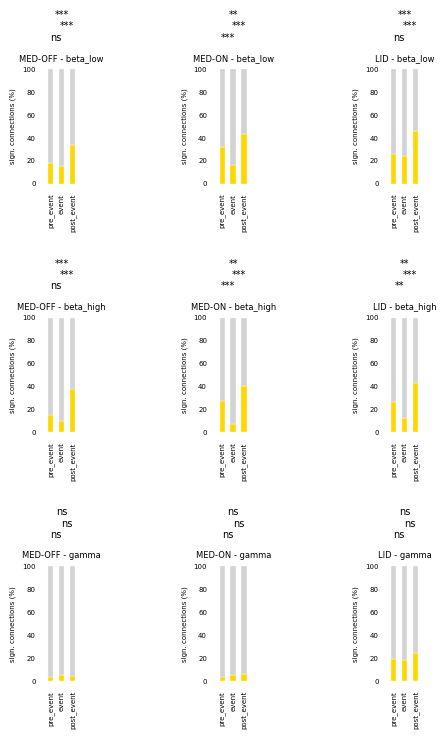

In [22]:
plt  = utils_plotting.get_figure_template()

ax1  = plt.subplot2grid((77, 66), (0, 0)  , colspan=4, rowspan=14)
ax2  = plt.subplot2grid((77, 66), (0, 20) , colspan=4, rowspan=14)
ax3  = plt.subplot2grid((77, 66), (0, 40) , colspan=4, rowspan=14)

ax4  = plt.subplot2grid((77, 66), (30, 0) , colspan=4, rowspan=14)
ax5  = plt.subplot2grid((77, 66), (30, 20), colspan=4, rowspan=14)
ax6  = plt.subplot2grid((77, 66), (30, 40), colspan=4, rowspan=14)

ax7  = plt.subplot2grid((77, 66), (60, 0) , colspan=4, rowspan=14)
ax8  = plt.subplot2grid((77, 66), (60, 20), colspan=4, rowspan=14)
ax9  = plt.subplot2grid((77, 66), (60, 40), colspan=4, rowspan=14)

plot_significance_distribution_for_frequency_band(dataset, state="MED-OFF", freq="beta_low", alpha=0.05, axis=ax1)
plot_significance_distribution_for_frequency_band(dataset, state="MED-ON" , freq="beta_low", alpha=0.05, axis=ax2)
plot_significance_distribution_for_frequency_band(dataset, state="LID"    , freq="beta_low", alpha=0.05, axis=ax3)

plot_significance_distribution_for_frequency_band(dataset, state="MED-OFF", freq="beta_high", alpha=0.05, axis=ax4)
plot_significance_distribution_for_frequency_band(dataset, state="MED-ON" , freq="beta_high", alpha=0.05, axis=ax5)
plot_significance_distribution_for_frequency_band(dataset, state="LID"    , freq="beta_high", alpha=0.05, axis=ax6)

plot_significance_distribution_for_frequency_band(dataset, state="MED-OFF", freq="gamma", alpha=0.05, axis=ax7)
plot_significance_distribution_for_frequency_band(dataset, state="MED-ON" , freq="gamma", alpha=0.05, axis=ax8)
plot_significance_distribution_for_frequency_band(dataset, state="LID"    , freq="gamma", alpha=0.05, axis=ax9)

plt.savefig(DATA_IO.path_figure + f"trgc/dist_of_significant_connection.svg", dpi=1200)

# 5. Plotting Average Net [Cortex-STN] TRGC for Cortex

In [11]:
taps_gc = pd.read_pickle(DATA_IO.path_events + "granger_causality/ipsilateral_connectivity.pkl")
dataset = taps_gc[['source_type', 'source_hemisphere', 'source_channel', 'target_type', 'target_hemisphere', 'target_channel', 
                   'patient', 'state', 'segment', 'direction','gc_theta', 'gc_alpha','gc_beta_low', 'gc_beta_high', 'gc_gamma']]

df_lfp  = dataset[dataset.source_type=="LFP"]
df_ecog = dataset[dataset.source_type=="ECOG"]

# measure the net drive
dataset_net = utils_trgc.compute_net_gc(dataset)

## 5.1 TFGC MED-OFF

In [9]:
vmin = -0.005; vmax=0.005

utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-OFF", segment = "pre_event" , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-OFF", segment = "event"     , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-OFF", segment = "post_event", frequency_band = "gamma", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-OFF", segment = "pre_event" , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-OFF", segment = "event"     , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-OFF", segment = "post_event", frequency_band = "beta_high", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-OFF", segment = "pre_event" , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-OFF", segment = "event"     , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-OFF", segment = "post_event", frequency_band = "beta_low", vmin=vmin, vmax=vmax)

## 5.2 TFGC MED-ON

In [11]:
vmin = -0.005; vmax=0.005

utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-ON", segment = "pre_event" , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-ON", segment = "event"     , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-ON", segment = "post_event", frequency_band = "gamma", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-ON", segment = "pre_event" , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-ON", segment = "event"     , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-ON", segment = "post_event", frequency_band = "beta_high", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-ON", segment = "pre_event" , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-ON", segment = "event"     , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "MED-ON", segment = "post_event", frequency_band = "beta_low", vmin=vmin, vmax=vmax)

## 5.3 TFGC LID

In [39]:
vmin = -0.005; vmax=0.005

utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "LID", segment = "pre_event" , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "LID", segment = "event"     , frequency_band = "gamma", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "LID", segment = "post_event", frequency_band = "gamma", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "LID", segment = "pre_event" , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "LID", segment = "event"     , frequency_band = "beta_high", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "LID", segment = "post_event", frequency_band = "beta_high", vmin=vmin, vmax=vmax)

utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "LID", segment = "pre_event" , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "LID", segment = "event"     , frequency_band = "beta_low", vmin=vmin, vmax=vmax)
utils_plotting_trgc.plot_net_gc_connectivity_for_ECOG_channels(dataset_net, state = "LID", segment = "post_event", frequency_band = "beta_low", vmin=vmin, vmax=vmax)

# 6. Statistical Tests For Net [Cortex - STN] Granger Causality

In [6]:
taps_gc = pd.read_pickle(DATA_IO.path_events + "granger_causality/ipsilateral_connectivity.pkl")
dataset = taps_gc[['source_type', 'source_hemisphere', 'source_channel', 'target_type', 'target_hemisphere', 'target_channel', 
                   'patient', 'state', 'segment', 'direction','gc_theta', 'gc_alpha','gc_beta_low', 'gc_beta_high', 'gc_gamma']]

## 6.1 Cortex vs STN

In [7]:
results_lme_direction = []

for frequency_band in ["theta", "alpha", "beta_low", "beta_high", "gamma"]:
    for state in ["MED-OFF", "MED-ON", "LID"]:
        for segment in ["pre_event", "event", "post_event"]:
        
            results_lme_direction.append(utils_trgc.compare_net_trgc_strength_between_directions(dataset=dataset, state=state, 
                                                                                                 frequency_band=frequency_band, segment=segment))

results_lme_direction                     = pd.concat(results_lme_direction, ignore_index=True)
# correct the p-values for each comparison separately (i.e., correct all p-values within state and frequency bands)
results_lme_direction["pvalue_corrected"] = results_lme_direction.groupby(["state","frequency_band"])["pvalue"].transform(lambda p: multipletests(p, method="holm")[1])

In [9]:
results_lme_direction[results_lme_direction.pvalue_corrected<=0.05]

,reference_group,comparison_group,state,segment,frequency_band,coefficient,z_score,pvalue,CI_lower,CI_upper,pvalue_corrected
15,STN,CORTEX,LID,pre_event,alpha,0.004544,2.670764,7.567872e-03,0.001209,0.007878,2.270362e-02
18,STN,CORTEX,MED-OFF,pre_event,beta_low,-0.002872,-2.406526,1.610507e-02,-0.005211,-0.000533,3.221014e-02
20,STN,CORTEX,MED-OFF,post_event,beta_low,-0.010072,-3.347368,8.158295e-04,-0.015969,-0.004174,2.447488e-03
25,STN,CORTEX,LID,event,beta_low,0.001789,2.556276,1.057991e-02,0.000417,0.003161,3.173972e-02
26,STN,CORTEX,LID,post_event,beta_low,-0.007340,-2.393459,1.669037e-02,-0.013350,-0.001329,3.338074e-02
27,STN,CORTEX,MED-OFF,pre_event,beta_high,-0.005417,-3.367980,7.572098e-04,-0.008570,-0.002265,1.514420e-03
29,STN,CORTEX,MED-OFF,post_event,beta_high,-0.023522,-6.047903,1.467433e-09,-0.031145,-0.015899,4.402298e-09
30,STN,CORTEX,MED-ON,pre_event,beta_high,-0.010308,-2.558416,1.051501e-02,-0.018204,-0.002411,3.154504e-02
34,STN,CORTEX,LID,event,beta_high,0.001816,2.466497,1.364417e-02,0.000373,0.003259,2.728835e-02
35,STN,CORTEX,LID,post_event,beta_high,-0.013335,-2.826015,4.713107e-03,-0.022583,-0.004086,1.413932e-02


## 6.2 Clinical States

In [68]:
results_lme_direction_and_state = []

for frequency_band in ["theta", "alpha", "beta_low", "beta_high", "gamma"]:
    for segment in ["pre_event", "event", "post_event"]:
        
        results_lme_direction_and_state.append(utils_trgc.compare_net_trgc_strength_between_directions_and_states(dataset=dataset, frequency_band=frequency_band, 
                                                                                                                  segment=segment))

results_lme_direction_and_state                     = pd.concat(results_lme_direction_and_state, ignore_index=True)
# correct the p-values for each comparison separately (i.e., correct all p-values within compared states and frequency bands)
results_lme_direction_and_state["pvalue_corrected"] = results_lme_direction_and_state.groupby(["reference_state","frequency_band"])["pvalue"].transform(lambda p: multipletests(p, method="holm")[1])
results_sig                                         = results_lme_direction_and_state[results_lme_direction_and_state.pvalue_corrected<=0.05]

In [70]:
results_sig

,reference_region,comparison_region,reference_state,comparison_state,segment,frequency_band,coefficient,z_score,pvalue,CI_lower,CI_upper,pvalue_corrected
10,STN,CORTEX,MED-OFF,MED-ON,post_event,alpha,0.013834,3.230289,0.001237,0.005440,0.022227,0.003710
16,STN,CORTEX,MED-OFF,MED-ON,post_event,beta_low,0.010571,2.529509,0.011422,0.002380,0.018762,0.034267
17,STN,CORTEX,MED-ON,LID,post_event,beta_low,-0.011298,-2.804781,0.005035,-0.019193,-0.003403,0.015105


In [164]:
def plot_trgc_state_comparison(df, reference_state, comparison_state, segment, ax=None):

    df_plot                   = df[(df["reference_state"] == reference_state) & (df["comparison_state"] == comparison_state) & (df["segment"] == segment)].copy()
    df_plot["frequency_band"] = pd.Categorical(df_plot["frequency_band"], categories=["theta", "alpha", "beta_low", "beta_high", "gamma"], ordered=False)
    # plot each frequency band individually
    x_vals = range(len(df_plot))
    
    for i, row in enumerate(df_plot.itertuples()):
        
        if row.pvalue_corrected >= 0.05 : color = "#ccccccff"   # not significant
        elif row.coefficient > 0        : color = "#ff0000ff"   # significant positive (stronger cortical influence)
        else                            : color = "#0101ffff"   # significant negative (stronger subthalamic influence)
        
        ax.errorbar(x=row.coefficient, y=i, xerr=[[row.coefficient - row.CI_lower], [row.CI_upper - row.coefficient]],
                    fmt='o', color=color, ecolor=color, elinewidth=1, capsize=2, markersize=2)
    
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_yticks(x_vals)
    ax.set_yticklabels(df_plot["frequency_band"], rotation=0)
    ax.set_ylabel("")
    ax.set_title(f"{reference_state} → {comparison_state} | Segment: {segment}", fontsize=utils_plotting.LABEL_SIZE)
    ax.set_xlim([-0.025, 0.025])
    ax.grid(False)
    ax.invert_yaxis()
    utils_plotting.set_axis(ax)
    
    return ax


<Figure size 640x480 with 0 Axes>

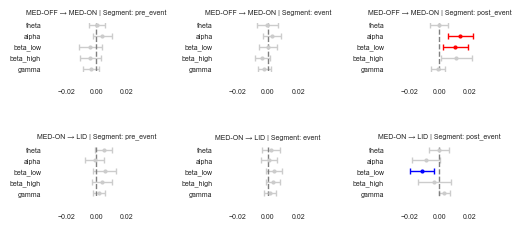

In [166]:
plt = utils_plotting.get_figure_template()
ax1 = plt.subplot2grid((77, 66), (0, 0)   , colspan=9, rowspan=6)
ax2 = plt.subplot2grid((77, 66), (0, 20)  , colspan=9, rowspan=6)
ax3 = plt.subplot2grid((77, 66), (0, 40)  , colspan=9, rowspan=6)

ax4 = plt.subplot2grid((77, 66), (15, 0)  , colspan=9, rowspan=6)
ax5 = plt.subplot2grid((77, 66), (15, 20) , colspan=9, rowspan=6)
ax6 = plt.subplot2grid((77, 66), (15, 40) , colspan=9, rowspan=6)


plot_trgc_state_comparison(df=results_lme_direction_and_state, reference_state="MED-OFF", comparison_state="MED-ON", segment="pre_event" , ax=ax1)
plot_trgc_state_comparison(df=results_lme_direction_and_state, reference_state="MED-OFF", comparison_state="MED-ON", segment="event"     , ax=ax2)
plot_trgc_state_comparison(df=results_lme_direction_and_state, reference_state="MED-OFF", comparison_state="MED-ON", segment="post_event", ax=ax3)

plot_trgc_state_comparison(df=results_lme_direction_and_state, reference_state="MED-ON", comparison_state="LID", segment="pre_event" , ax=ax4)
plot_trgc_state_comparison(df=results_lme_direction_and_state, reference_state="MED-ON", comparison_state="LID", segment="event"     , ax=ax5)
plot_trgc_state_comparison(df=results_lme_direction_and_state, reference_state="MED-ON", comparison_state="LID", segment="post_event", ax=ax6)

plt.savefig(DATA_IO.path_figure + "granger_causality/lme_net_TFGC_between_states.svg", dpi=1200)

## 6.3 Event Segments

In [10]:
results_lme_direction_and_segment = []


for state in ["MED-OFF", "MED-ON", "LID"]:
    for frequency_band in ["theta", "alpha", "beta_low", "beta_high", "gamma"]:
        results_lme_direction_and_segment.append(utils_trgc.compare_net_trgc_strength_between_segments_within_state(dataset=dataset, state=state,
                                                                                                                    frequency_band=frequency_band))

results_lme_direction_and_segment                     = pd.concat(results_lme_direction_and_segment, ignore_index=True)
# correct the p-values for each comparison separately (i.e., correct all p-values within compared states and frequency bands)
results_lme_direction_and_segment["pvalue_corrected"] = results_lme_direction_and_segment.groupby(["reference_segment","frequency_band"])["pvalue"].transform(lambda p: multipletests(p, method="holm")[1])
results_sig                                           = results_lme_direction_and_segment[results_lme_direction_and_segment.pvalue_corrected<=0.05]

In [11]:
results_sig

,reference_region,comparison_region,reference_segment,comparison_segment,state,frequency_band,coefficient,z_score,pvalue,CI_lower,CI_upper,pvalue_corrected
4,STN,CORTEX,pre_event,event,MED-OFF,beta_low,0.004203,3.404290,6.633640e-04,0.001783,0.006623,1.990092e-03
5,STN,CORTEX,event,post_event,MED-OFF,beta_low,-0.009987,-4.329726,1.492950e-05,-0.014509,-0.005466,2.985899e-05
6,STN,CORTEX,pre_event,event,MED-OFF,beta_high,0.005127,3.842129,1.219718e-04,0.002511,0.007742,3.659153e-04
7,STN,CORTEX,event,post_event,MED-OFF,beta_high,-0.018969,-7.150600,8.639933e-13,-0.024168,-0.013769,2.591980e-12
13,STN,CORTEX,event,post_event,MED-ON,alpha,0.011818,3.056732,2.237641e-03,0.004240,0.019396,6.712924e-03
22,STN,CORTEX,pre_event,event,LID,alpha,-0.004523,-3.593145,3.267103e-04,-0.006990,-0.002056,9.801310e-04
25,STN,CORTEX,event,post_event,LID,beta_low,-0.008959,-4.455356,8.375398e-06,-0.012900,-0.005018,2.512619e-05
26,STN,CORTEX,pre_event,event,LID,beta_high,0.005383,3.105888,1.897087e-03,0.001986,0.008780,3.794174e-03
27,STN,CORTEX,event,post_event,LID,beta_high,-0.013979,-4.797254,1.608555e-06,-0.019690,-0.008267,3.217109e-06


In [12]:
def plot_trgc_segment_comparison(df, reference_segment, comparison_segment, state, ax=None):

    df_plot                   = df[(df["reference_segment"] == reference_segment) & (df["comparison_segment"] == comparison_segment) & (df["state"] == state)].copy()
    df_plot["frequency_band"] = pd.Categorical(df_plot["frequency_band"], categories=["theta", "alpha", "beta_low", "beta_high", "gamma"], ordered=False)
    x_vals                    = range(len(df_plot))

    for i, row in enumerate(df_plot.itertuples()):
        if (row.pvalue_corrected >= 0.05) : color = "#ccccccff"    # not significant
        elif (row.coefficient > 0)        : color = "#ff0000ff"    # significant positive (stronger cortical influence)
        else                              : color = "#0101ffff"    # significant negative (stronger subthalamic influence)

        ax.errorbar(x=row.coefficient, y=i, xerr=[[row.coefficient - row.CI_lower], [row.CI_upper - row.coefficient]],
                    fmt='o', color=color, ecolor=color, elinewidth=1, capsize=2, markersize=2)

    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_yticks(x_vals)
    ax.set_yticklabels(df_plot["frequency_band"], rotation=0)
    ax.set_ylabel("")
    ax.set_title(f"{reference_segment} → {comparison_segment} | State: {state}",
                 fontsize=utils_plotting.LABEL_SIZE)
    ax.set_xlim([-0.025, 0.025])
    ax.grid(False)
    ax.invert_yaxis()
    utils_plotting.set_axis(ax)

    return ax


<Figure size 640x480 with 0 Axes>

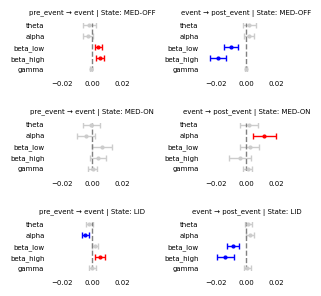

In [18]:
plt = utils_plotting.get_figure_template()

ax1 = plt.subplot2grid((77, 66), (0 , 0 ), colspan=9, rowspan=6)
ax2 = plt.subplot2grid((77, 66), (0 , 18), colspan=9, rowspan=6)
ax3 = plt.subplot2grid((77, 66), (12, 0 ), colspan=9, rowspan=6)
ax4 = plt.subplot2grid((77, 66), (12, 18), colspan=9, rowspan=6)
ax5 = plt.subplot2grid((77, 66), (24, 0 ), colspan=9, rowspan=6)
ax6 = plt.subplot2grid((77, 66), (24, 18), colspan=9, rowspan=6)

ax1 = plot_trgc_segment_comparison(results_lme_direction_and_segment, reference_segment="pre_event", comparison_segment="event"     , state="MED-OFF", ax=ax1)
ax2 = plot_trgc_segment_comparison(results_lme_direction_and_segment, reference_segment="event"    , comparison_segment="post_event", state="MED-OFF", ax=ax2)
ax3 = plot_trgc_segment_comparison(results_lme_direction_and_segment, reference_segment="pre_event", comparison_segment="event"     , state="MED-ON" , ax=ax3)
ax4 = plot_trgc_segment_comparison(results_lme_direction_and_segment, reference_segment="event"    , comparison_segment="post_event", state="MED-ON" , ax=ax4)
ax5 = plot_trgc_segment_comparison(results_lme_direction_and_segment, reference_segment="pre_event", comparison_segment="event"     , state="LID"    , ax=ax5)
ax6 = plot_trgc_segment_comparison(results_lme_direction_and_segment, reference_segment="event"    , comparison_segment="post_event", state="LID"    , ax=ax6)

plt.savefig(DATA_IO.path_figure + "granger_causality/lme_net_TFGC_between_segments.svg", dpi=1200)